In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [ ]:
import keras
from keras import layers
import os

# 1. Carichiamo le immagini direttamente dalla cartella in automatico!
# Keras ridimensiona le foto, crea i batch e divide in Train e Validation da solo.

# 1. Puntiamo DIRETTAMENTE alle cartelle che contengono le 6 categorie!
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

IMG_SIZE = (150, 150) # Dimensione a cui ridimensionare le foto (es. 64x64 pixel)
BATCH_SIZE = 32

# Set di Training (80% dei dati)
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"\n🎉 PERFETTO! Classi reali trovate ({num_classes}):", class_names)


🎉 PERFETTO! Classi reali trovate (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
model = keras.Sequential([
    # 1. Input Layer Esplicito (sintassi pulita Keras 3)
    layers.Input(shape=(150, 150, 3)),

    # 2. Normalizzazione Pixel (da 0..255 a 0..1)
    layers.Rescaling(1./255),

    # 3. Blocco Conv 1: Dettagli di base (32 filtri)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4. Blocco Conv 2: Forme e texture (64 filtri)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 5. Blocco Conv 3: Oggetti e paesaggi complessi (128 filtri)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 6. Classificatore Finale
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),

    # 6 Neuroni (1 per classe) con Softmax per avere percentuali!
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
# Compilazione
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Mostra un riassunto dell'architettura
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. Training! (Passi direttamente il dataset generato da Keras)
model.fit(train_ds, validation_data=val_ds, epochs=6)

Epoch 1/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7825 - loss: 0.5930 - val_accuracy: 0.7780 - val_loss: 0.5965
Epoch 2/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7956 - loss: 0.5626 - val_accuracy: 0.8060 - val_loss: 0.5306
Epoch 3/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8041 - loss: 0.5330 - val_accuracy: 0.8113 - val_loss: 0.5268
Epoch 4/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8175 - loss: 0.5123 - val_accuracy: 0.8153 - val_loss: 0.5031
Epoch 5/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8192 - loss: 0.5010 - val_accuracy: 0.8133 - val_loss: 0.5312
Epoch 6/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8282 - loss: 0.4809 - val_accuracy: 0.8297 - val_loss: 0.4678


In [ ]:
import numpy as np
import tensorflow as tf
import keras

# 1. Carichiamo un'immagine di test (es. dal folder seg_pred del dataset)
img_path = os.path.join(path, "seg_pred", "seg_pred", "10004.jpg")

# Carichiamo l'immagine con le STESSE dimensioni usate nel training (150x150)
img = keras.utils.load_img(img_path, target_size=(150, 150))

# 2. Convertiamo l'immagine in un Array NumPy
img_array = keras.utils.img_to_array(img)

# 3. Aggiungiamo la dimensione del Batch!
# Il modello si aspetta un input con forma (1, 150, 150, 3) e non (150, 150, 3)
img_array = tf.expand_dims(img_array, 0)

# 4. PREDIZIONE!
predictions = model.predict(img_array)

# 5. Interpretiamo il risultato
# predictions[0] contiene 6 percentuali (una per ogni classe)
predicted_class_index = np.argmax(predictions[0]) # Prende l'indice della probabilità più alta
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(predictions[0]) * 100

print(f"📸 Foto analizzata: {img_path}")
print(f"🎯 Il modello dice che è: **{predicted_class_name.upper()}** con una sicurezza del {confidence:.2f}%!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
📸 Foto analizzata: /kaggle/input/intel-image-classification/seg_pred/seg_pred/10004.jpg
🎯 Il modello dice che è: **BUILDINGS** con una sicurezza del 81.06%!


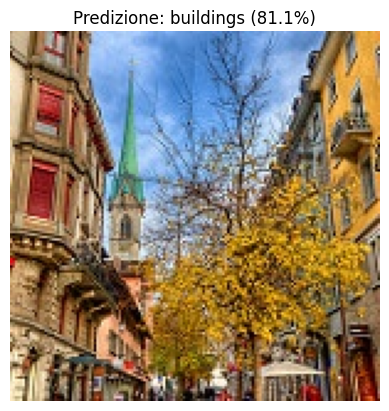

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predizione: {predicted_class_name} ({confidence:.1f}%)")
plt.axis("off")
plt.show()